Cell 1: Imports and Environment Configuration



In [ ]:
import os
import collections
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from google.colab import files

# Upload your kaggle.json file
files.upload()

# Set up Kaggle credentials directory
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download and unzip the data
!kaggle datasets download -d anjosut/galaxy-zoo-classification
!unzip galaxy-zoo-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: Train_images/Train_images/spiral/421176.jpg  
  inflating: Train_images/Train_images/spiral/421301.jpg  
  inflating: Train_images/Train_images/spiral/421414.jpg  
  inflating: Train_images/Train_images/spiral/421634.jpg  
  inflating: Train_images/Train_images/spiral/421747.jpg  
  inflating: Train_images/Train_images/spiral/421867.jpg  
  inflating: Train_images/Train_images/spiral/422201.jpg  
  inflating: Train_images/Train_images/spiral/422204.jpg  
  inflating: Train_images/Train_images/spiral/422227.jpg  
  inflating: Train_images/Train_images/spiral/422375.jpg  
  inflating: Train_images/Train_images/spiral/422518.jpg  
  inflating: Train_images/Train_images/spiral/422558.jpg  
  inflating: Train_images/Train_images/spiral/422673.jpg  
  inflating: Train_images/Train_images/spiral/422771.jpg  
  inflating: Train_images/Train_images/spiral/422893.jpg  
  inflating: Train_images/Train_images/spiral/423000.jpg  
  inf

Cell 2: Verifying Directory Contents


In [ ]:
# Check root files
print("Root items:", os.listdir())

# Check entire directory map structure
for root, dirs, files in os.walk("."):
    print(root)
    print(dirs[:5])
    print(files[:5])
    print("-"*50)

Root items: ['.config', 'galaxy-zoo-classification.zip', 'Train_images', 'kaggle.json', 'train_label.csv', 'sample_data']
.
['.config', 'Train_images', 'sample_data']
['galaxy-zoo-classification.zip', 'kaggle.json', 'train_label.csv']
--------------------------------------------------
./.config
['configurations', 'logs']
['hidden_gcloud_config_universe_descriptor_data_cache_configs.db', '.last_opt_in_prompt.yaml', 'active_config', 'gce', '.last_survey_prompt.yaml']
--------------------------------------------------
./.config/configurations
[]
['config_default']
--------------------------------------------------
./.config/logs
['2026.05.12']
[]
--------------------------------------------------
./.config/logs/2026.05.12
[]
['13.35.26.553372.log', '13.35.03.183347.log', '13.35.15.619517.log', '13.34.42.645568.log', '13.35.27.356656.log']
--------------------------------------------------
./Train_images
['Train_images']
[]
--------------------------------------------------
./Train_images/

Cell 3: Pipeline Initialization and Data Loading


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
DATASET_PATH = "Train_images/Train_images"

# Generate training data splits
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Generate validation data splits
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Normalize data pipeline inputs to [0, 1] scale
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (x / 255.0, y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (x / 255.0, y)).prefetch(AUTOTUNE)

Found 28793 files belonging to 5 classes.
Using 23035 files for training.
Found 28793 files belonging to 5 classes.
Using 5758 files for validation.
Classes: ['Cigar-shaped smooth', 'In between smooth', 'completely round smooth', 'edge-on', 'spiral']


Cell 4: Constructing and Running Base Model Feature Training


In [ ]:
# Load pre-trained ResNet50 base and freeze it
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

# Build top classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', name="embedding"),
    layers.Dropout(0.4),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("--- Training Base Feature Extractor (10 Epochs) ---")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

--- Training Base Feature Extractor (10 Epochs) ---
Epoch 1/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 108s 128ms/step - accuracy: 0.2852 - loss: 1.4421 - val_accuracy: 0.2732 - val_loss: 1.4203
Epoch 2/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 79s 110ms/step - accuracy: 0.2892 - loss: 1.4270 - val_accuracy: 0.2855 - val_loss: 1.4164
Epoch 3/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 84s 113ms/step - accuracy: 0.2900 - loss: 1.4199 - val_accuracy: 0.2855 - val_loss: 1.4093
Epoch 4/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - accuracy: 0.2925 - loss: 1.4167 - val_accuracy: 0.2732 - val_loss: 1.4174
Epoch 5/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 81s 112ms/step - accuracy: 0.2925 - loss: 1.4170 - val_accuracy: 0.2855 - val_loss: 1.4039
Epoch 6/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 80s 111ms/step - accuracy: 0.2942 - loss: 1.4093 - val_accuracy: 0.2855 - val_loss: 1.4006
Epoch 7/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 85s 118ms/step - accuracy: 0.2926 - loss: 1.3985 - val_accuracy: 0.2855 - val_loss: 1.3821
Epoch 8/10
720/720 ━━━━━━━━━━━

Cell 5: Deep Backbone Fine-Tuning

In [ ]:
# Unfreeze top 30 layers of ResNet50 backbone
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("--- Fine-Tuning the Top Layers (5 Epochs) ---")
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

# Crucial point: Save the model AFTER fine-tuning to preserve high-accuracy representations
model.save("galaxy_resnet50.h5")

--- Fine-Tuning the Top Layers (5 Epochs) ---
Epoch 1/5
720/720 ━━━━━━━━━━━━━━━━━━━━ 140s 164ms/step - accuracy: 0.5586 - loss: 0.9847 - val_accuracy: 0.4496 - val_loss: 1.2456
Epoch 2/5
720/720 ━━━━━━━━━━━━━━━━━━━━ 106s 147ms/step - accuracy: 0.6695 - loss: 0.7774 - val_accuracy: 0.4880 - val_loss: 1.4074
Epoch 3/5
720/720 ━━━━━━━━━━━━━━━━━━━━ 140s 145ms/step - accuracy: 0.7032 - loss: 0.7024 - val_accuracy: 0.3593 - val_loss: 1.9210
Epoch 4/5
720/720 ━━━━━━━━━━━━━━━━━━━━ 108s 150ms/step - accuracy: 0.7166 - loss: 0.6720 - val_accuracy: 0.4347 - val_loss: 2.9453
Epoch 5/5
720/720 ━━━━━━━━━━━━━━━━━━━━ 109s 151ms/step - accuracy: 0.7373 - loss: 0.6367 - val_accuracy: 0.4404 - val_loss: 2.4374


Cell 6: Building the Dedicated Feature Extraction Model

In [ ]:
# Reconstruct explicitly to handle structural embedding connections cleanly
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
embedding = layers.Dense(256, activation="relu", name="embedding")(x)
x = layers.Dropout(0.4)(embedding)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = models.Model(inputs, outputs)

# Load the fine-tuned model checkpoint file
model.load_weights("galaxy_resnet50.h5", by_name=True, skip_mismatch=True)

# Separate out the intermediate features layer
feature_extractor = models.Model(
    inputs=model.input,
    outputs=model.get_layer("embedding").output
)
print("Feature extractor ready ✔")

Feature extractor ready ✔


Cell 7: Normal Galaxies Sub-dataset Filtering

In [ ]:
NORMAL_CLASSES = ["spiral", "completely round smooth", "In between smooth"]
normal_idx = [class_names.index(c) for c in NORMAL_CLASSES]

def is_normal(image, label):
    return tf.reduce_any(tf.equal(label, normal_idx))

normal_ds = train_ds.unbatch().filter(is_normal).batch(32)
print("Normal dataset ready")

Normal dataset ready


Cell 8: Generating Embedding Vectors for VAE Modeling


In [ ]:
print("Extracting features from normal dataset...")
normal_features = []
for x, y in normal_ds:
    f = feature_extractor(x)
    normal_features.append(f.numpy())
normal_features = np.concatenate(normal_features)
print("Normal features shape:", normal_features.shape)

print("Extracting features from validation dataset...")
all_features = []
all_images = []
all_labels = []
for x, y in val_ds:
    f = feature_extractor(x)
    all_features.append(f.numpy())
    all_images.append(x.numpy())
    all_labels.append(y.numpy())

all_features = np.concatenate(all_features)
all_images = np.concatenate(all_images)
all_labels = np.concatenate(all_labels)
print("Validation features shape:", all_features.shape)

Extracting features from normal dataset...
Normal features shape: (19456, 256)
Extracting features from validation dataset...
Validation features shape: (5758, 256)


Cell 9: Variational Autoencoder Class Setup

In [ ]:
LATENT_DIM = 16
INPUT_DIM = normal_features.shape[1]

# Encoder
enc_in = layers.Input(shape=(INPUT_DIM,))
x = layers.Dense(128, activation="relu")(enc_in)
x = layers.Dense(64, activation="relu")(x)
z_mean = layers.Dense(LATENT_DIM)(x)
z_log_var = layers.Dense(LATENT_DIM)(x)

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

z = Sampling()([z_mean, z_log_var])
encoder = models.Model(enc_in, [z_mean, z_log_var, z])

# Decoder
dec_in = layers.Input(shape=(LATENT_DIM,))
x = layers.Dense(64, activation="relu")(dec_in)
x = layers.Dense(128, activation="relu")(x)
dec_out = layers.Dense(INPUT_DIM)(x)
decoder = models.Model(dec_in, dec_out)

# Custom VAE execution model
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            recon = self.decoder(z)
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - recon), axis=1))
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            loss = recon_loss + kl_loss

        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": loss, "recon": recon_loss, "kl": kl_loss}

vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(), run_eagerly=True)

Cell 10: VAE Optimization Phase

In [ ]:
print("--- Training VAE for Anomaly Detection ---")
vae.fit(normal_features, epochs=40, batch_size=128)

--- Training VAE for Anomaly Detection ---
Epoch 1/40
152/152 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - kl: 7.6803 - loss: 16.7018 - recon: 9.0215 
Epoch 2/40
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 94ms/step - kl: 6.1748 - loss: 11.7275 - recon: 5.5526
Epoch 3/40
152/152 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - kl: 5.5004 - loss: 9.5571 - recon: 4.0567
Epoch 4/40
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - kl: 5.3906 - loss: 9.1009 - recon: 3.7103
Epoch 5/40
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - kl: 4.9985 - loss: 8.3902 - recon: 3.3917
Epoch 6/40
152/152 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - kl: 4.9012 - loss: 7.5976 - recon: 2.6964
Epoch 7/40
152/152 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - kl: 4.6551 - loss: 7.2644 - recon: 2.6094
Epoch 8/40
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - kl: 4.4043 - loss: 6.7676 - recon: 2.3633
Epoch 9/40
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - kl: 4.3683 - loss: 6.8943 - recon: 2.5261
Epoch 10/40
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - kl: 4.2766 - lo

Cell 11: Plot Loss Metrics

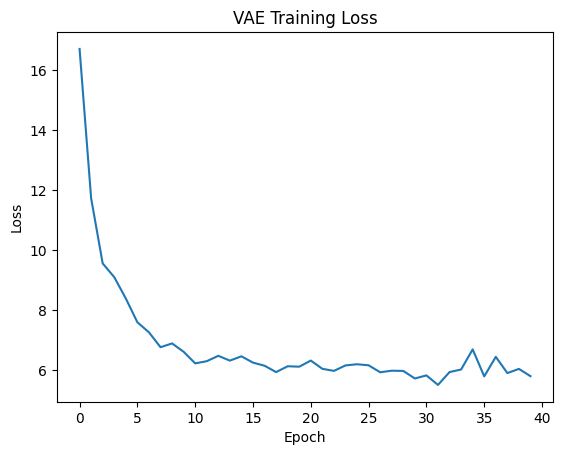

In [ ]:
plt.plot(vae.history.history["loss"])
plt.title("VAE Training Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

Cell 12: Measuring Reconstruction Fidelity

180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


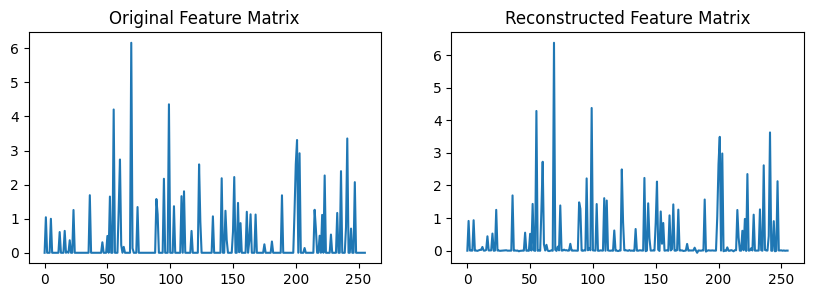

In [ ]:
z_mean, _, z = encoder.predict(all_features)
reconstructed = decoder.predict(z)

# Visualization comparison profile check
idx = 5
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.title("Original Feature Matrix")
plt.plot(all_features[idx])

plt.subplot(1, 2, 2)
plt.title("Reconstructed Feature Matrix")
plt.plot(reconstructed[idx])
plt.show()

Cell 13: Anomaly Identification (Threshold Cutoffs)

In [ ]:
# Generate Mean Squared Reconstruction Errors
mse = np.mean(np.square(all_features - reconstructed), axis=1)

# Designate upper 5% highest error values as unique rare shapes
threshold = np.percentile(mse, 95)
anomalies = mse > threshold

print("Total galaxies evaluated:", len(mse))
print("Rare galaxies identified:", np.sum(anomalies))

Total galaxies evaluated: 5758
Rare galaxies identified: 288


Cell 14: Visualizing Anomalies and Distribution Mapping

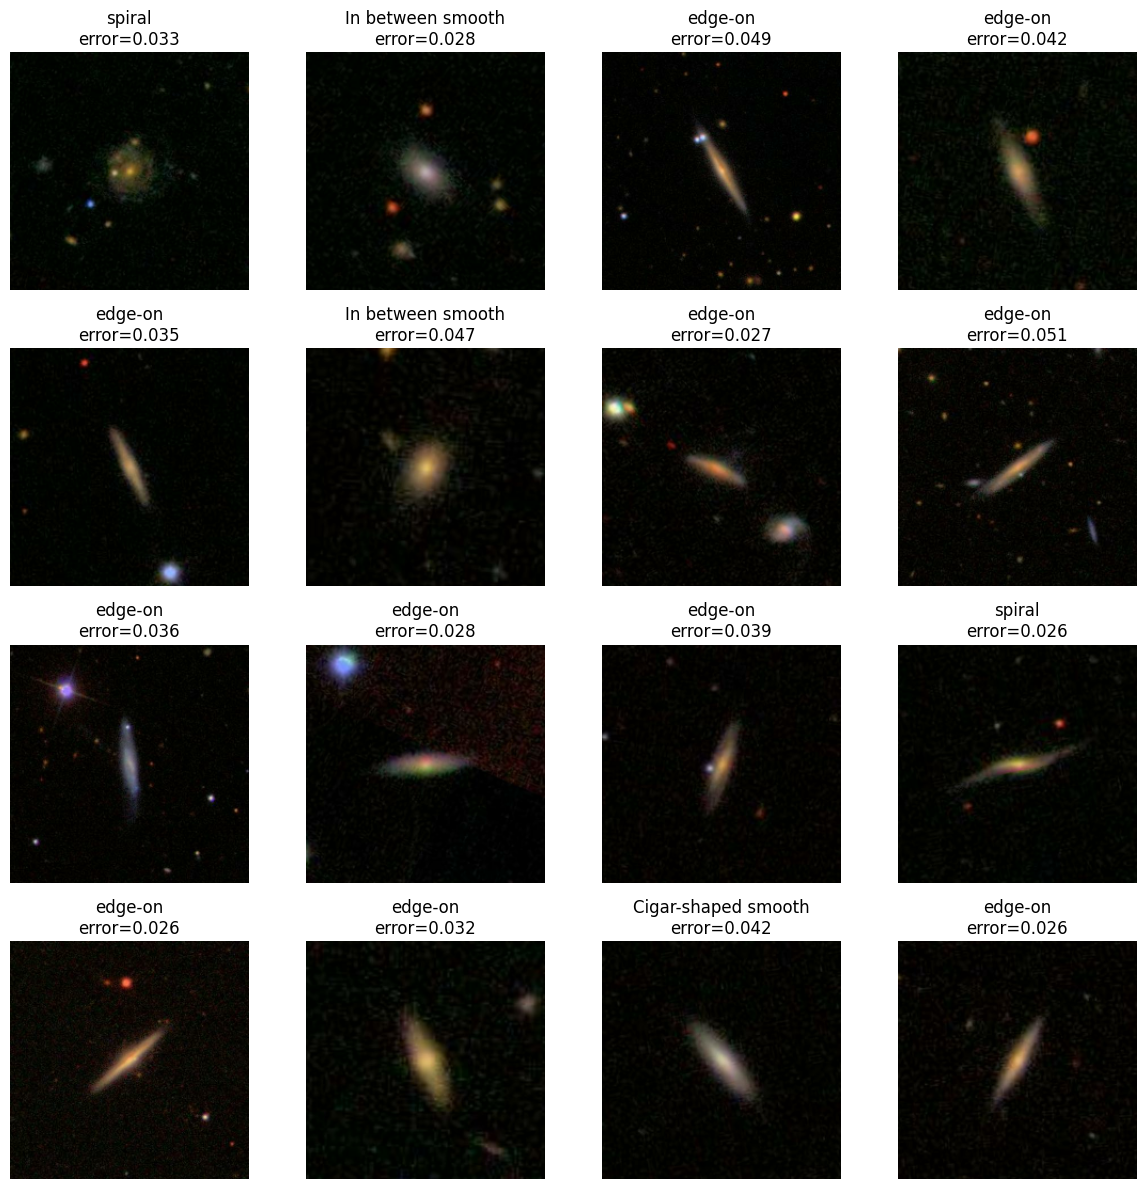

Distribution of anomalies mapped per class type:
Counter({np.int32(3): 200, np.int32(2): 31, np.int32(4): 26, np.int32(1): 21, np.int32(0): 10})


In [ ]:
idxs = np.where(anomalies)[0]

plt.figure(figsize=(12, 12))
for i, idx in enumerate(idxs[:16]):
    plt.subplot(4, 4, i+1)
    plt.imshow(all_images[idx])
    plt.title(f"{class_names[all_labels[idx]]}\nerror={mse[idx]:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Distribution of anomalies mapped per class type:")
print(collections.Counter(all_labels[idxs]))

Cell 15: Baseline Validation Assessment

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("--- Evaluation BEFORE Class Balancing ---")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

--- Evaluation BEFORE Class Balancing ---
                         precision    recall  f1-score   support

    Cigar-shaped smooth       0.00      0.00      0.00       115
      In between smooth       0.02      0.01      0.01      1573
completely round smooth       0.02      0.01      0.01      1644
                edge-on       0.00      0.00      0.00       788
                 spiral       0.19      0.50      0.28      1638

               accuracy                           0.14      5758
              macro avg       0.05      0.10      0.06      5758
           weighted avg       0.07      0.14      0.08      5758



Cell 16: Class Weight Imbalance Processing

In [ ]:
y_train = []
for _, labels in train_ds.unbatch():
    y_train.append(labels.numpy())
y_train = np.array(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))
print("Computed balancing class weights:", class_weights)

Computed balancing class weights: {0: np.float64(9.928879310344827), 1: np.float64(0.7092056650246306), 2: np.float64(0.6782979976442874), 3: np.float64(1.4789727126805778), 4: np.float64(0.7469195849546044)}


Cell 17: Final Weighted Target Classification Learning Run

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("--- Training Classifier WITH Class Weights ---")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

--- Training Classifier WITH Class Weights ---
Epoch 1/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 132s 156ms/step - accuracy: 0.5131 - loss: 1.0796 - val_accuracy: 0.4793 - val_loss: 1.6844
Epoch 2/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 104s 144ms/step - accuracy: 0.5650 - loss: 0.9647 - val_accuracy: 0.2850 - val_loss: 1.8759
Epoch 3/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 107s 148ms/step - accuracy: 0.5802 - loss: 0.9449 - val_accuracy: 0.2845 - val_loss: 8.8756
Epoch 4/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 139s 145ms/step - accuracy: 0.5943 - loss: 0.9165 - val_accuracy: 0.2845 - val_loss: 7.3388
Epoch 5/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 107s 149ms/step - accuracy: 0.6070 - loss: 0.8887 - val_accuracy: 0.2845 - val_loss: 5.0795
Epoch 6/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 108s 150ms/step - accuracy: 0.6162 - loss: 0.8669 - val_accuracy: 0.6469 - val_loss: 0.7949
Epoch 7/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 108s 150ms/step - accuracy: 0.6313 - loss: 0.8249 - val_accuracy: 0.2845 - val_loss: 11.0179
Epoch 8/10
720/720 ━━━━━━━━━

Cell 18: Evaluating Final Weighted Network System

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("--- Final Evaluation AFTER Class Balancing ---")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

--- Final Evaluation AFTER Class Balancing ---
                         precision    recall  f1-score   support

    Cigar-shaped smooth       0.00      0.00      0.00       115
      In between smooth       0.00      0.00      0.00      1573
completely round smooth       0.29      1.00      0.45      1644
                edge-on       0.00      0.00      0.00       788
                 spiral       0.00      0.00      0.00      1638

               accuracy                           0.29      5758
              macro avg       0.06      0.20      0.09      5758
           weighted avg       0.08      0.29      0.13      5758



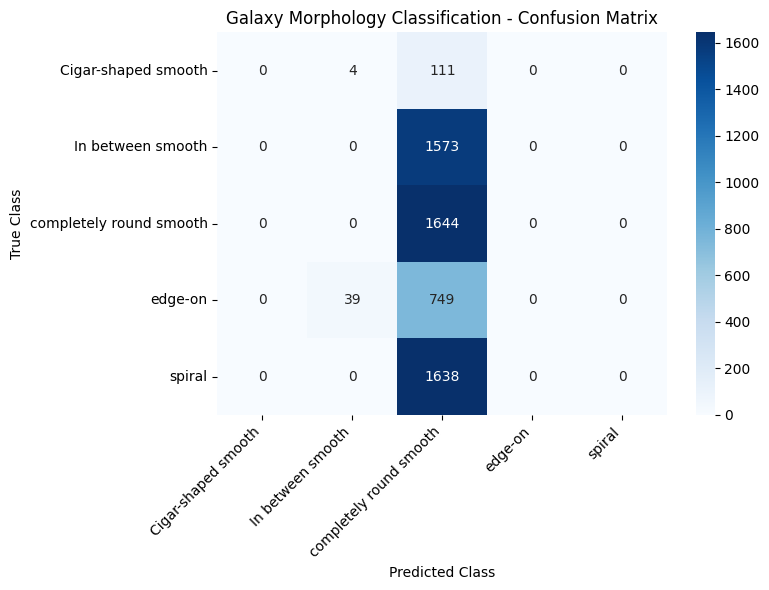

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Galaxy Morphology Classification - Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

Main Classifier Training Curves (Accuracy & Loss)


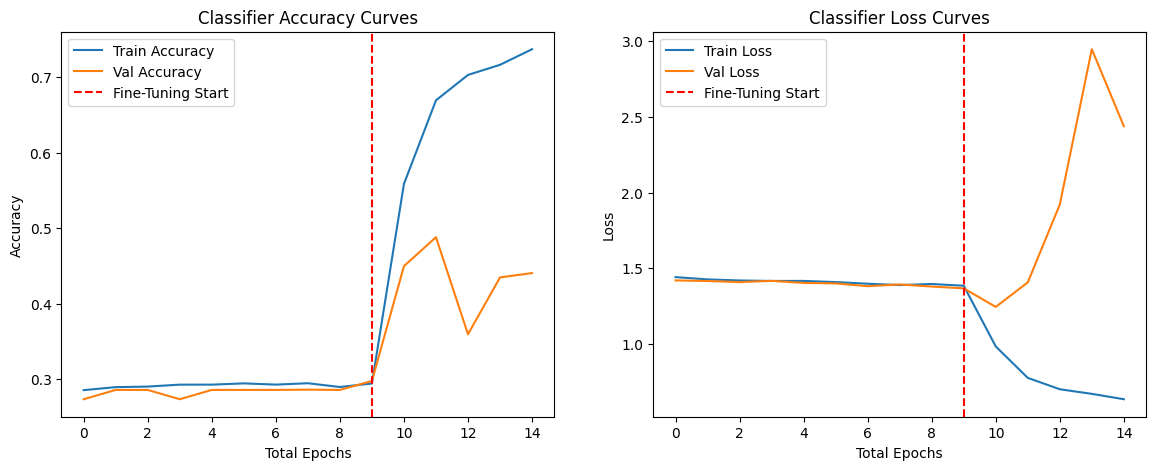

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'] + history_finetune.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'] + history_finetune.history['val_accuracy'], label='Val Accuracy')
ax1.axvline(x=9, color='r', linestyle='--', label='Fine-Tuning Start')
ax1.set_title('Classifier Accuracy Curves')
ax1.set_xlabel('Total Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Loss
ax2.plot(history.history['loss'] + history_finetune.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'] + history_finetune.history['val_loss'], label='Val Loss')
ax2.axvline(x=9, color='r', linestyle='--', label='Fine-Tuning Start')
ax2.set_title('Classifier Loss Curves')
ax2.set_xlabel('Total Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.savefig('classifier_training_curves.png', dpi=300)
plt.show()